In [1]:
%%capture --no-stderr
%pip install --quiet -U langgraph


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


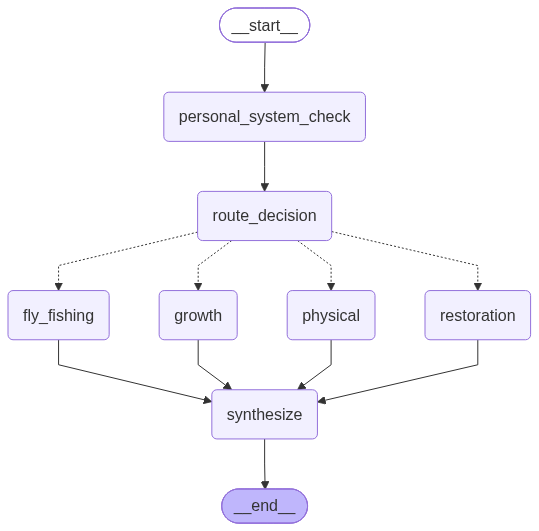

In [4]:
from IPython.display import Image, display
from langgraph.graph import END, START, StateGraph

from hobbymaxxing.nodes.fly_fishing import fly_fishing
from hobbymaxxing.nodes.growth import growth
from hobbymaxxing.nodes.orchestrator import ALL_DOMAINS, route, route_decision, synthesize
from hobbymaxxing.nodes.personal_system import personal_system_check
from hobbymaxxing.nodes.physical import physical
from hobbymaxxing.nodes.restoration import restoration
from hobbymaxxing.state import State

_DOMAIN_NODES = {
    "fly_fishing": fly_fishing,
    "physical": physical,
    "restoration": restoration,
    "growth": growth,
}


builder = StateGraph(State)

builder.add_node("personal_system_check", personal_system_check)
builder.add_node("route_decision", route_decision)
for name, fn in _DOMAIN_NODES.items():
    builder.add_node(name, fn)
builder.add_node("synthesize", synthesize)

builder.add_edge(START, "personal_system_check")
builder.add_edge("personal_system_check", "route_decision")
builder.add_conditional_edges(
    "route_decision", route, list(_DOMAIN_NODES.keys())
)
for name in ALL_DOMAINS:
    builder.add_edge(name, "synthesize")
builder.add_edge("synthesize", END)

graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))